In [2]:

# AI Powered Alternate Credit Scoring
#This project aims to predict loan default risk using machine learning models on alternative financial data.

In [3]:
!pip install xgboost


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import pandas as pd 
import numpy as np
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.metrics import accuracy_score,classification_report,roc_auc_score,roc_curve,confusion_matrix
from sklearn.model_selection import train_test_split,cross_val_score,RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
import seaborn as sns
import matplotlib.pyplot as plt

In [5]:
df=pd.read_csv("application_train.csv")

In [6]:
df

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
307506,456251,0,Cash loans,M,N,N,0,157500.0,254700.0,27558.0,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
307507,456252,0,Cash loans,F,N,Y,0,72000.0,269550.0,12001.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
307508,456253,0,Cash loans,F,N,Y,0,153000.0,677664.0,29979.0,...,0,0,0,0,1.0,0.0,0.0,1.0,0.0,1.0
307509,456254,1,Cash loans,F,N,Y,0,171000.0,370107.0,20205.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [7]:
df.shape

(307511, 122)

In [8]:
df.columns

Index(['SK_ID_CURR', 'TARGET', 'NAME_CONTRACT_TYPE', 'CODE_GENDER',
       'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL',
       'AMT_CREDIT', 'AMT_ANNUITY',
       ...
       'FLAG_DOCUMENT_18', 'FLAG_DOCUMENT_19', 'FLAG_DOCUMENT_20',
       'FLAG_DOCUMENT_21', 'AMT_REQ_CREDIT_BUREAU_HOUR',
       'AMT_REQ_CREDIT_BUREAU_DAY', 'AMT_REQ_CREDIT_BUREAU_WEEK',
       'AMT_REQ_CREDIT_BUREAU_MON', 'AMT_REQ_CREDIT_BUREAU_QRT',
       'AMT_REQ_CREDIT_BUREAU_YEAR'],
      dtype='object', length=122)

In [9]:
df.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [10]:
df.describe()

,SK_ID_CURR,TARGET,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
count,307511.000000,307511.000000,307511.000000,3.075110e+05,3.075110e+05,307499.000000,3.072330e+05,307511.000000,307511.000000,307511.000000,...,307511.000000,307511.000000,307511.000000,307511.000000,265992.000000,265992.000000,265992.000000,265992.000000,265992.000000,265992.000000
mean,278180.518577,0.080729,0.417052,1.687979e+05,5.990260e+05,27108.573909,5.383962e+05,0.020868,-16036.995067,63815.045904,...,0.008130,0.000595,0.000507,0.000335,0.006402,0.007000,0.034362,0.267395,0.265474,1.899974
std,102790.175348,0.272419,0.722121,2.371231e+05,4.024908e+05,14493.737315,3.694465e+05,0.013831,4363.988632,141275.766519,...,0.089798,0.024387,0.022518,0.018299,0.083849,0.110757,0.204685,0.916002,0.794056,1.869295
min,100002.000000,0.000000,0.000000,2.565000e+04,4.500000e+04,1615.500000,4.050000e+04,0.000290,-25229.000000,-17912.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,189145.500000,0.000000,0.000000,1.125000e+05,2.700000e+05,16524.000000,2.385000e+05,0.010006,-19682.000000,-2760.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,278202.000000,0.000000,0.000000,1.471500e+05,5.135310e+05,24903.000000,4.500000e+05,0.018850,-15750.000000,-1213.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
75%,367142.500000,0.000000,1.000000,2.025000e+05,8.086500e+05,34596.000000,6.795000e+05,0.028663,-12413.000000,-289.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000
max,456255.000000,1.000000,19.000000,1.170000e+08,4.050000e+06,258025.500000,4.050000e+06,0.072508,-7489.000000,365243.000000,...,1.000000,1.000000,1.000000,1.000000,4.000000,9.000000,8.000000,27.000000,261.000000,25.000000


In [11]:
#The dataset contains 307,511 records and 122 features including financial and demographic information.

In [12]:
df.isnull().sum()

SK_ID_CURR                        0
TARGET                            0
NAME_CONTRACT_TYPE                0
CODE_GENDER                       0
FLAG_OWN_CAR                      0
                              ...  
AMT_REQ_CREDIT_BUREAU_DAY     41519
AMT_REQ_CREDIT_BUREAU_WEEK    41519
AMT_REQ_CREDIT_BUREAU_MON     41519
AMT_REQ_CREDIT_BUREAU_QRT     41519
AMT_REQ_CREDIT_BUREAU_YEAR    41519
Length: 122, dtype: int64

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 122 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(65), int64(41), object(16)
memory usage: 286.2+ MB


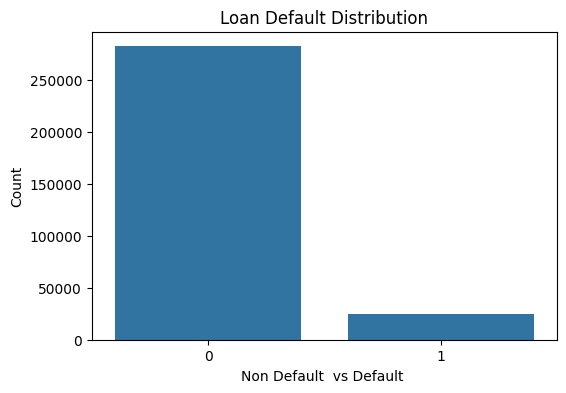

In [14]:
plt.figure(figsize=(6,4))
sns.countplot(x='TARGET', data=df)
plt.title("Loan Default Distribution")
plt.xlabel("Non Default  vs Default ")
plt.ylabel("Count")
plt.show()

In [15]:
#Insight:
#The dataset is highly imbalanced with majority of non-default cases. This indicates the need for techniques like SMOTE.

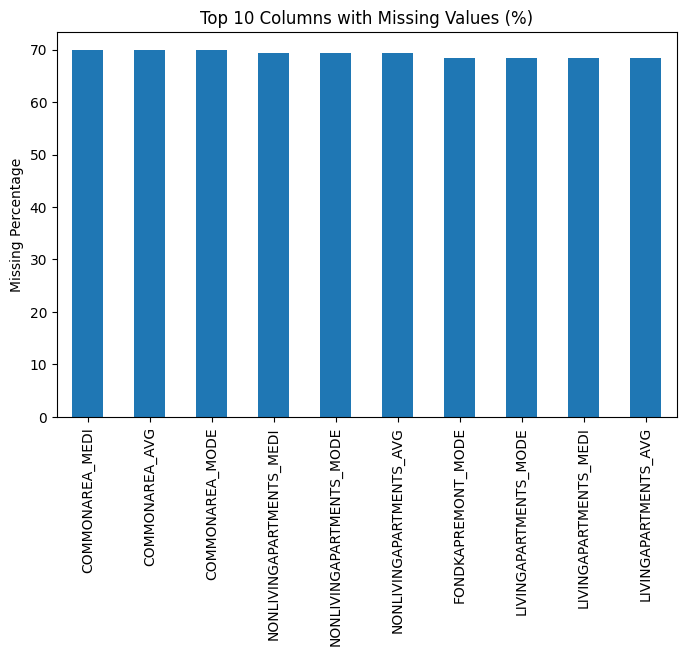

In [16]:
missing = df.isnull().mean()*100
missing = missing[missing > 0].sort_values(ascending=False)
plt.figure(figsize=(8,5))
missing.head(10).plot(kind='bar')
plt.title("Top 10 Columns with Missing Values (%)")
plt.ylabel("Missing Percentage")
plt.show()

In [17]:
#Insight:
#Several features have very high missing values (~65–70%), especially related to apartment and building characteristics.  
#These columns provide limited information and will be removed during preprocessing to improve model performance.

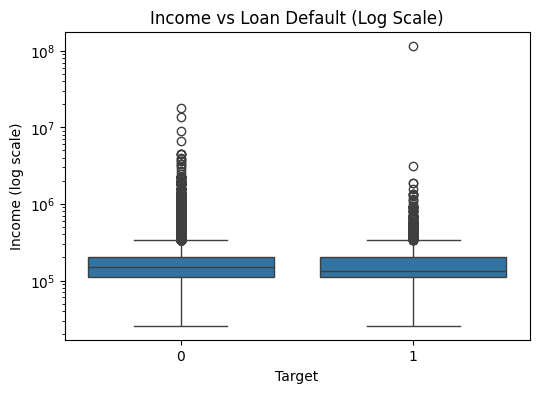

In [18]:
plt.figure(figsize=(6,4))
sns.boxplot(x='TARGET', y='AMT_INCOME_TOTAL', data=df)
plt.yscale('log') 
plt.title("Income vs Loan Default (Log Scale)")
plt.xlabel("Target")
plt.ylabel("Income (log scale)")
plt.show()

In [19]:
#Insight:
#Income distribution is similar for both defaulters and non-defaulters, with many outliers present. This indicates that income alone is not a strong predictor of loan default.

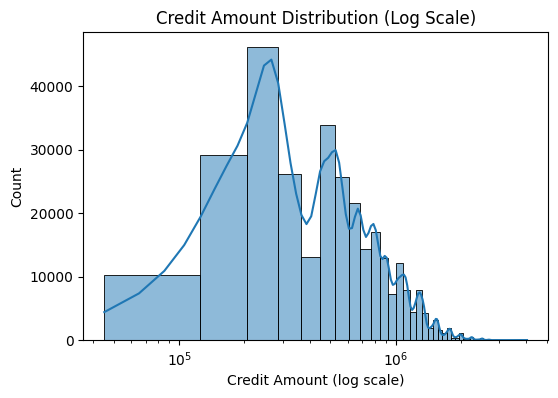

In [20]:
plt.figure(figsize=(6,4))
sns.histplot(df['AMT_CREDIT'], bins=50, kde=True)
plt.xscale('log')
plt.title("Credit Amount Distribution (Log Scale)")
plt.xlabel("Credit Amount (log scale)")
plt.show()

In [21]:
#Insight:
#The distribution of credit amount is highly right-skewed, indicating that most customers take relatively smaller loans while a few customers take very large loans.
#The presence of extreme values suggests outliers in the dataset. Applying log scaling helps in better visualization of the distribution.
#This indicates that credit amount alone may not linearly influence default risk and requires further analysis with other features.

In [22]:
m=df.isnull().mean()*100

In [23]:
m

SK_ID_CURR                     0.000000
TARGET                         0.000000
NAME_CONTRACT_TYPE             0.000000
CODE_GENDER                    0.000000
FLAG_OWN_CAR                   0.000000
                                ...    
AMT_REQ_CREDIT_BUREAU_DAY     13.501631
AMT_REQ_CREDIT_BUREAU_WEEK    13.501631
AMT_REQ_CREDIT_BUREAU_MON     13.501631
AMT_REQ_CREDIT_BUREAU_QRT     13.501631
AMT_REQ_CREDIT_BUREAU_YEAR    13.501631
Length: 122, dtype: float64

In [24]:
m.sort_values(ascending=False)

COMMONAREA_MEDI             69.872297
COMMONAREA_AVG              69.872297
COMMONAREA_MODE             69.872297
NONLIVINGAPARTMENTS_MODE    69.432963
NONLIVINGAPARTMENTS_AVG     69.432963
                              ...    
NAME_HOUSING_TYPE            0.000000
NAME_FAMILY_STATUS           0.000000
NAME_EDUCATION_TYPE          0.000000
NAME_INCOME_TYPE             0.000000
SK_ID_CURR                   0.000000
Length: 122, dtype: float64

In [25]:
threshold=50
dropcol=m[m>threshold].index

In [26]:
dropcol

Index(['OWN_CAR_AGE', 'EXT_SOURCE_1', 'APARTMENTS_AVG', 'BASEMENTAREA_AVG',
       'YEARS_BUILD_AVG', 'COMMONAREA_AVG', 'ELEVATORS_AVG', 'ENTRANCES_AVG',
       'FLOORSMIN_AVG', 'LANDAREA_AVG', 'LIVINGAPARTMENTS_AVG',
       'LIVINGAREA_AVG', 'NONLIVINGAPARTMENTS_AVG', 'NONLIVINGAREA_AVG',
       'APARTMENTS_MODE', 'BASEMENTAREA_MODE', 'YEARS_BUILD_MODE',
       'COMMONAREA_MODE', 'ELEVATORS_MODE', 'ENTRANCES_MODE', 'FLOORSMIN_MODE',
       'LANDAREA_MODE', 'LIVINGAPARTMENTS_MODE', 'LIVINGAREA_MODE',
       'NONLIVINGAPARTMENTS_MODE', 'NONLIVINGAREA_MODE', 'APARTMENTS_MEDI',
       'BASEMENTAREA_MEDI', 'YEARS_BUILD_MEDI', 'COMMONAREA_MEDI',
       'ELEVATORS_MEDI', 'ENTRANCES_MEDI', 'FLOORSMIN_MEDI', 'LANDAREA_MEDI',
       'LIVINGAPARTMENTS_MEDI', 'LIVINGAREA_MEDI', 'NONLIVINGAPARTMENTS_MEDI',
       'NONLIVINGAREA_MEDI', 'FONDKAPREMONT_MODE', 'HOUSETYPE_MODE',
       'WALLSMATERIAL_MODE'],
      dtype='object')

In [27]:
df = df.drop(columns=dropcol)

In [28]:
df

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
307506,456251,0,Cash loans,M,N,N,0,157500.0,254700.0,27558.0,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
307507,456252,0,Cash loans,F,N,Y,0,72000.0,269550.0,12001.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
307508,456253,0,Cash loans,F,N,Y,0,153000.0,677664.0,29979.0,...,0,0,0,0,1.0,0.0,0.0,1.0,0.0,1.0
307509,456254,1,Cash loans,F,N,Y,0,171000.0,370107.0,20205.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [29]:
df.shape

(307511, 81)

In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Data columns (total 81 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   SK_ID_CURR                    307511 non-null  int64  
 1   TARGET                        307511 non-null  int64  
 2   NAME_CONTRACT_TYPE            307511 non-null  object 
 3   CODE_GENDER                   307511 non-null  object 
 4   FLAG_OWN_CAR                  307511 non-null  object 
 5   FLAG_OWN_REALTY               307511 non-null  object 
 6   CNT_CHILDREN                  307511 non-null  int64  
 7   AMT_INCOME_TOTAL              307511 non-null  float64
 8   AMT_CREDIT                    307511 non-null  float64
 9   AMT_ANNUITY                   307499 non-null  float64
 10  AMT_GOODS_PRICE               307233 non-null  float64
 11  NAME_TYPE_SUITE               306219 non-null  object 
 12  NAME_INCOME_TYPE              307511 non-nul

In [31]:
df = df.drop(columns=['SK_ID_CURR'])

In [32]:
df

,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,351000.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,1129500.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,135000.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,297000.0,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,513000.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
307506,0,Cash loans,M,N,N,0,157500.0,254700.0,27558.0,225000.0,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
307507,0,Cash loans,F,N,Y,0,72000.0,269550.0,12001.5,225000.0,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
307508,0,Cash loans,F,N,Y,0,153000.0,677664.0,29979.0,585000.0,...,0,0,0,0,1.0,0.0,0.0,1.0,0.0,1.0
307509,1,Cash loans,F,N,Y,0,171000.0,370107.0,20205.0,319500.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [33]:
features = [
    "DAYS_EMPLOYED",
    "DAYS_BIRTH",
    "AMT_CREDIT",
    "AMT_INCOME_TOTAL",
    "AMT_ANNUITY",
    "EXT_SOURCE_2",
    "EXT_SOURCE_3",
    "NAME_INCOME_TYPE",
    "NAME_EDUCATION_TYPE"
]

In [34]:
x = df[features]
y = df["TARGET"]

In [35]:
x

,DAYS_EMPLOYED,DAYS_BIRTH,AMT_CREDIT,AMT_INCOME_TOTAL,AMT_ANNUITY,EXT_SOURCE_2,EXT_SOURCE_3,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE
0,-637,-9461,406597.5,202500.0,24700.5,0.262949,0.139376,Working,Secondary / secondary special
1,-1188,-16765,1293502.5,270000.0,35698.5,0.622246,NaN,State servant,Higher education
2,-225,-19046,135000.0,67500.0,6750.0,0.555912,0.729567,Working,Secondary / secondary special
3,-3039,-19005,312682.5,135000.0,29686.5,0.650442,NaN,Working,Secondary / secondary special
4,-3038,-19932,513000.0,121500.0,21865.5,0.322738,NaN,Working,Secondary / secondary special
...,...,...,...,...,...,...,...,...,...
307506,-236,-9327,254700.0,157500.0,27558.0,0.681632,NaN,Working,Secondary / secondary special
307507,365243,-20775,269550.0,72000.0,12001.5,0.115992,NaN,Pensioner,Secondary / secondary special
307508,-7921,-14966,677664.0,153000.0,29979.0,0.535722,0.218859,Working,Higher education
307509,-4786,-11961,370107.0,171000.0,20205.0,0.514163,0.661024,Commercial associate,Secondary / secondary special


In [39]:
y

0         1
1         0
2         0
3         0
4         0
         ..
307506    0
307507    0
307508    0
307509    1
307510    0
Name: TARGET, Length: 307511, dtype: int64

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

In [ ]:
catcols = x.select_dtypes(include=['object']).columns

In [ ]:
catcols

Index(['NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE'], dtype='object')

In [ ]:
numcols = x.select_dtypes(include=['number']).columns

In [ ]:
numcols

NameError: name 'numcols' is not defined

In [ ]:
for col in numcols:
    skew_val = X[col].skew()
    
    if abs(skew_val) < 0.5:
        print(col, "→ Normal")
    else:
        print(col, "→ Skewed")

In [ ]:
numpipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

In [ ]:
catpipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(drop='first', handle_unknown='ignore'))
])

In [ ]:
preprocessor = ColumnTransformer([
    ('num',numpipeline,numcols),
    ('cat',catpipeline,catcols)
])

In [ ]:
preprocessor

,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'median'
,fill_value,None


In [ ]:
!pip install --upgrade scikit-learn imbalanced-learn



[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
from imblearn.pipeline import Pipeline

In [ ]:
pipeline = Pipeline([
    ('preprocessor', preprocessor),   # handles text → numbers
    ('smote', SMOTE(random_state=42)), # now safe
    ('model', LogisticRegression())
])

In [ ]:
pipeline.fit(x_train, y_train)

,steps,"[('preprocessor', ...), ('smote', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [ ]:
# Logistic Regression
param_lr = {
    'model__C': [0.01, 0.1, 1, 10]
}
param_rf = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [10, 20, None],
    'model__min_samples_split': [2, 5],
    'model__min_samples_leaf': [1, 2]
}
param_xgb = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [10, 20, None],
    'model__learning_rate': [0.01, 0.05, 0.1],
    'model__subsample': [0.8, 1],
    'model__colsample_bytree': [0.8, 1]
}

In [ ]:
lr = LogisticRegression(max_iter=1000,class_weight='balanced')
rf = RandomForestClassifier(class_weight='balanced')
scale_pos_weight = (len(y_train[y_train==0]) / len(y_train[y_train==1]))
xgb = XGBClassifier(eval_metric='logloss',scale_pos_weight=scale_pos_weight)

In [ ]:
lr_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('model', lr)
])

In [ ]:
rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('model', rf)   # 🔥 IMPORTANT
])

In [ ]:
xgb_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('model', xgb)
])

In [ ]:
print(lr_pipeline)
print(rf_pipeline)
print(xgb_pipeline)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['DAYS_EMPLOYED', 'DAYS_BIRTH', 'AMT_CREDIT', 'AMT_INCOME_TOTAL',
       'AMT_ANNUITY', 'EXT_SOURCE_2', 'EXT_SOURCE_3'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                          

In [ ]:
# Logistic Regression
lr_search = RandomizedSearchCV(lr_pipeline, param_lr, n_iter=4, scoring='roc_auc', cv=2, n_jobs=1)
lr_search.fit(x_train, y_train)
best_lr = lr_search.best_estimator_
 #Random Forest
rf_search = RandomizedSearchCV(rf_pipeline, param_rf, n_iter=4, scoring='roc_auc', cv=2, n_jobs=1)
rf_search.fit(x_train, y_train)
best_rf = rf_search.best_estimator_
# XGBoost
xgb_search = RandomizedSearchCV(xgb_pipeline, param_xgb, n_iter=4, scoring='roc_auc', cv=2, n_jobs=1)
xgb_search.fit(x_train, y_train)
best_xgb = xgb_search.best_estimator_

In [ ]:
lr_pred = best_lr.predict(x_test)
rf_pred = best_rf.predict(x_test)
y_prob = best_xgb.predict_proba(x_test)[:,1]
for t in [0.5, 0.3, 0.2, 0.15, 0.1]:
    y_pred_temp = (y_prob > t).astype(int)
    print(f"\nThreshold: {t}")
    print(classification_report(y_test, y_pred_temp))
xgb_pred = (y_prob > 0.1).astype(int)


Threshold: 0.5
              precision    recall  f1-score   support

           0       0.98      0.15      0.26     56554
           1       0.09      0.96      0.16      4949

    accuracy                           0.22     61503
   macro avg       0.53      0.56      0.21     61503
weighted avg       0.91      0.22      0.26     61503


Threshold: 0.3
              precision    recall  f1-score   support

           0       0.98      0.05      0.10     56554
           1       0.08      0.99      0.15      4949

    accuracy                           0.13     61503
   macro avg       0.53      0.52      0.13     61503
weighted avg       0.91      0.13      0.11     61503


Threshold: 0.2
              precision    recall  f1-score   support

           0       0.99      0.03      0.05     56554
           1       0.08      1.00      0.15      4949

    accuracy                           0.10     61503
   macro avg       0.54      0.51      0.10     61503
weighted avg       0.92   

In [ ]:
models = {
    "Logistic Regression": best_lr,
    "Random Forest": best_rf,
    "XGBoost": best_xgb
}
for name, model in models.items():
    print(f"\n{name}")
    y_prob = model.predict_proba(x_test)[:,1]
    if name == "XGBoost":
        y_pred = (y_prob > 0.1).astype(int)
    else:
        y_pred = model.predict(x_test)
    print(classification_report(y_test, y_pred))
    print("ROC-AUC:", roc_auc_score(y_test, y_prob))


Logistic Regression
              precision    recall  f1-score   support

           0       0.96      0.68      0.79     56554
           1       0.15      0.65      0.24      4949

    accuracy                           0.67     61503
   macro avg       0.55      0.66      0.52     61503
weighted avg       0.89      0.67      0.75     61503

ROC-AUC: 0.7276177329873741

Random Forest
              precision    recall  f1-score   support

           0       0.95      0.70      0.81     56554
           1       0.15      0.62      0.25      4949

    accuracy                           0.69     61503
   macro avg       0.55      0.66      0.53     61503
weighted avg       0.89      0.69      0.76     61503

ROC-AUC: 0.7220551792587537

XGBoost
              precision    recall  f1-score   support

           0       0.99      0.01      0.01     56554
           1       0.08      1.00      0.15      4949

    accuracy                           0.09     61503
   macro avg       0.53    

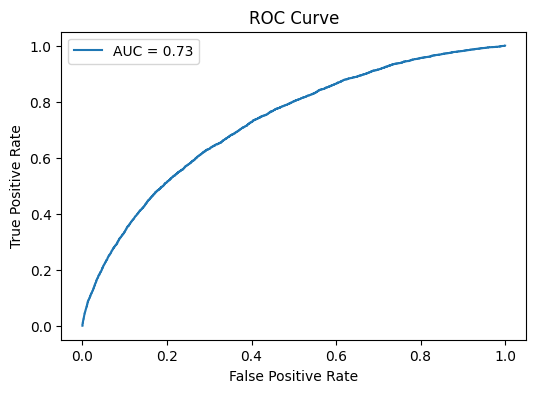

In [ ]:
y_prob = best_lr.predict_proba(x_test)[:,1]
# ROC values
fpr, tpr, _ = roc_curve(y_test, y_prob)
# AUC score
roc_auc = roc_auc_score(y_test, y_prob)
# plot
plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

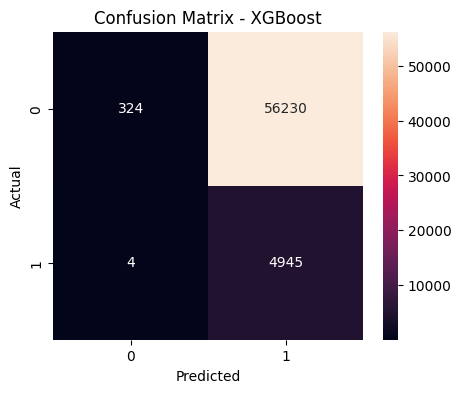

In [ ]:
y_prob = best_lr.predict_proba(x_test)[:,1]
xgb_pred = (y_prob > 0.1).astype(int)
cm = confusion_matrix(y_test, xgb_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - XGBoost")
plt.show()

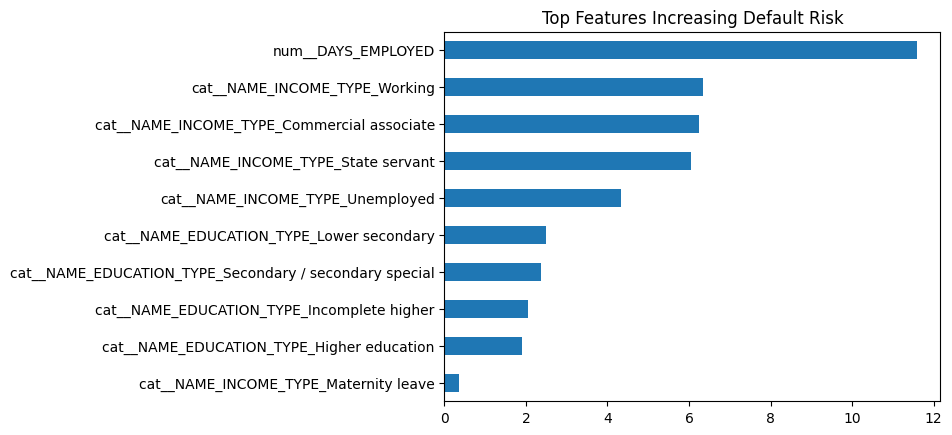

In [ ]:
importance = best_lr.named_steps['model'].coef_[0]

# Get feature names from fitted preprocessor
feature_names = best_lr.named_steps['preprocessor'].get_feature_names_out()

# Create series
feat_imp = pd.Series(importance, index=feature_names).sort_values()

# Plot top features
feat_imp.tail(10).plot(kind='barh')
plt.title("Top Features Increasing Default Risk")
plt.show()

In [ ]:
import pickle
pickle.dump(best_lr, open("credits_model.pkl", "wb"))